# Financial Econometrics I - Homework 1
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)
**Individual contributions**: 
Max Milde - Problem 1, Part 1; Zahid Pashayev - Problem 1, Part 1 & Problem 2 

**AI tool usage**: Claude (Anthropic) was primarily used to debug code, evaluate syntax, and provide suggestions about how to improve the layout of plots. The entire process of developing all of the statistical reasoning, making decisions about what to do with dirty data, and interpreting results was done in isolation from the AI, and was then reviewed and revised using AI feedback. The basic logic and structure of the analysis was developed by the team.

In [1]:
setwd("/Users/zp/Desktop/Financial_Econ")

In [2]:
library("ggplot2") #plotting
library("moments") #for skew and kurtosis
library("stabledist") #for stable dist curve
library("fBasics") #for stable dist param estimation


Attaching package: ‘fBasics’


The following objects are masked from ‘package:moments’:

    kurtosis, skewness




## Problem 1 Part 1

### 1.  Setup and Data Cleaning

In [3]:
base_path <- getwd()
print(base_path)

all_files <- c(list.files(file.path(base_path, "73267075"), full.names=TRUE),
               list.files(file.path(base_path, "54520099"), full.names=TRUE)
)

price_list_raw <- lapply(all_files, read.csv)
names(price_list_raw) <- tools::file_path_sans_ext(basename(all_files)) #get the names of all stocks
names(price_list_raw)

head(price_list_raw[["BIO"]]) #check the structure of the data

[1] "/Users/zp/Desktop/Financial_Econ"


[1] "BIO"  "CPT"  "ELV"  "FE"   "HCA"  "MKTX" "STT"  "XOM"  "BSX"  "CAH" 
[11] "CVX"  "GM"   "ICE"  "MCHP" "MDLZ" "PHM"  "QRVO" "WHR"

,Date,Open,High,Low,Close,Volume,Dividends,Stock.Splits
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,2019-01-02,229.73,231.23,226.73,228.08,165800,0,0
2,2019-01-03,228.18,231.26,223.89,224.3,180200,0,0
3,2019-01-04,224.50,228.34,224.11,226.28,446800,0,0
4,2019-01-07,227.52,234.82,227.26,233.67,354300,0,0
5,2019-01-08,235.00,236.91,232.48,235.53,235800,0,0
6,2019-01-09,236.61,241.40,236.61,237.37,266100,0,0


We do not observe duplicated tickers from both files, so no need for special naming. 

In [4]:

sapply(price_list_raw, colnames) #check if column names are same format
colnames(price_list_raw[["PHM"]])[2] <- "Close" #correct PHM Close column


$BIO
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CPT
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$ELV
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$FE
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$HCA
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MKTX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$STT
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$XOM
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$BSX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CAH
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CVX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$GM
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$ICE
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MCHP
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MDLZ
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$PHM
[1] "Date"   "Klose"  "Open"   "High"   "Low"    "Volume"

$QRVO
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$WHR
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

`PHM` contains "Klose" instead of "Close"

In [5]:
price_list <- lapply(price_list_raw, function(df) df[, c("Date", "Close")])
sapply(price_list, colnames)

BIO,CPT,ELV,FE,HCA,MKTX,STT,XOM,BSX,CAH,CVX,GM,ICE,MCHP,MDLZ,PHM,QRVO,WHR
Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date
Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close


We now have only the columns we are interested in.

In [6]:
str(price_list[["BIO"]]) #check for disparities
str(price_list[["CAH"]]) #need to reformat the column types

price_list <- lapply(price_list, function(df) {
    df$Date <- as.Date(df$Date)
    df$Close <- as.numeric(df$Close)
    return(df)
})

sapply(price_list, function(df) sum(is.na(df$Close)))

'data.frame':	1759 obs. of  2 variables:
 $ Date : chr  "2019-01-02" "2019-01-03" "2019-01-04" "2019-01-07" ...
 $ Close: chr  "228.08" "224.3" "226.28" "233.67" ...
'data.frame':	1758 obs. of  2 variables:
 $ Date : chr  "2019-01-02" "2019-01-03" "2019-01-04" "2019-01-07" ...
 $ Close: num  36.9 36.2 36.8 37.5 38.1 ...


Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   1    0    1    0    0    0    0    1    0    0    0    0    1    1    1    0 
QRVO  WHR 
   0    0

Need to drop NAs, so returns can be calculated properly.

In [7]:
price_list <- lapply(price_list, function(df) na.omit(df)) #remove NAs
sapply(price_list, function(df) sum(is.na(df$Close)))

sapply(price_list, function(df) sum(duplicated(df$Date))) #check for date duplicates

BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
QRVO  WHR 
   0    0

BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
QRVO  WHR 
   0    0

### 2. Returns

In [8]:
rets_list <- lapply(price_list, function(df){
    data.frame(
        Date = df$Date[-1], #remove 1st date as we don't have return for it
        rets = diff(log(df$Close)),
        rets_simple = diff(df$Close)/df$Close[-nrow(df)]
    )
})

head(rets_list[["BIO"]])

,Date,rets,rets_simple
,<date>,<dbl>,<dbl>
1,2019-01-03,-0.016712003,-0.016573132
2,2019-01-04,0.008788729,0.008827463
3,2019-01-07,0.032136693,0.032658653
4,2019-01-08,0.007928430,0.007959944
5,2019-01-09,0.007781811,0.007812168
6,2019-01-10,0.014637264,0.014744913


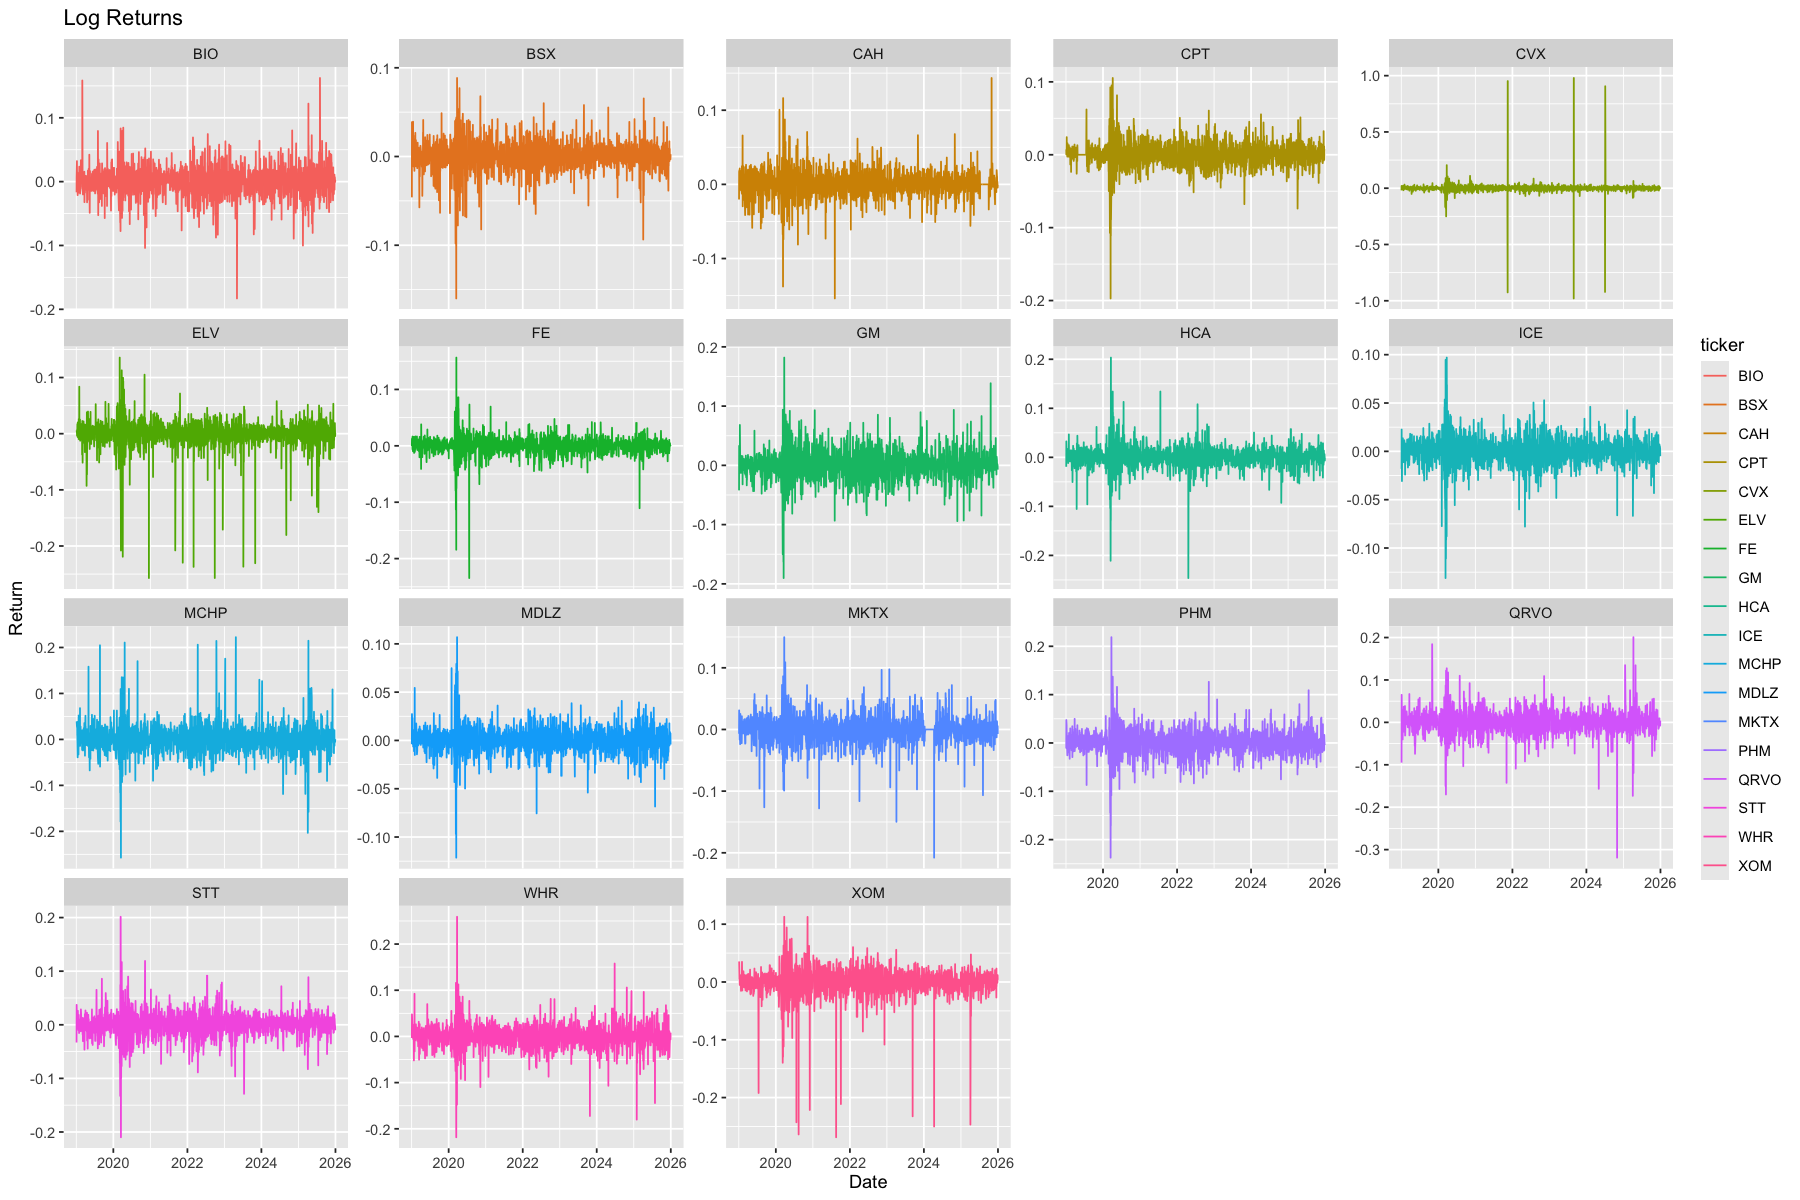

In [9]:
#combine the returns into a long data frame for ggplot2
rets_long <- do.call(rbind, lapply(names(rets_list), function(name) {
    data.frame(
        Date=rets_list[[name]]$Date,
        rets=rets_list[[name]]$rets,
        ticker=name
    )
}))

options(repr.plot.width=15, repr.plot.height=10)
ggplot(rets_long, aes(x=Date, y=rets, color=ticker)) +
    geom_line() + 
    facet_wrap(~ticker, scales="free_y") +
    labs(title="Log Returns", x="Date", y="Return")

From the plots, we observe that it is quite common to have daily retuns of &plusmn; 10-20%, even 30%. 

Nevertheless, `CVX` particularly stands out as it has several spikes of &plusmn; ~100% magnitude - likely a data issue.

### 3. Summary Statistics

In [ ]:
desc_stat <- do.call(rbind, lapply(names(rets_list), function(name){
    r <- rets_list[[name]]$rets
    data.frame(
        ticker = name,
        mean = mean(r),
        sd = sd(r),
        min = min(r),
        max = max(r),
        skew = skewness(r),
        kurt = kurtosis(r)
    )
}))

format(desc_stat, digits=2)

As expected, `CVX` is a clear outlier, with kurtosis of ~228 and extreme min (-98%) and max (98%) values.

Other larger leptokurtic tickers include: `FE`, `ELV` and `XOM`, all with kurtosis above 30.
They are also the most largely skewed - likely affected by real negative events. However, `CVX` does not have a skew of high magnitude (minimal), which suggests that it is most likely a data issue.

There do not appear to be other exteme or unusual statistics.

,Date,rets,rets_simple
,<date>,<dbl>,<dbl>
724,2021-11-15,-0.9256495,-0.6037261
725,2021-11-16,0.9520014,1.5908898
1170,2023-08-29,-0.9795360,-0.6245147
1171,2023-08-30,0.9793483,1.6627205
1381,2024-07-03,-0.9216510,-0.6021384
1382,2024-07-05,0.9059602,1.4743066


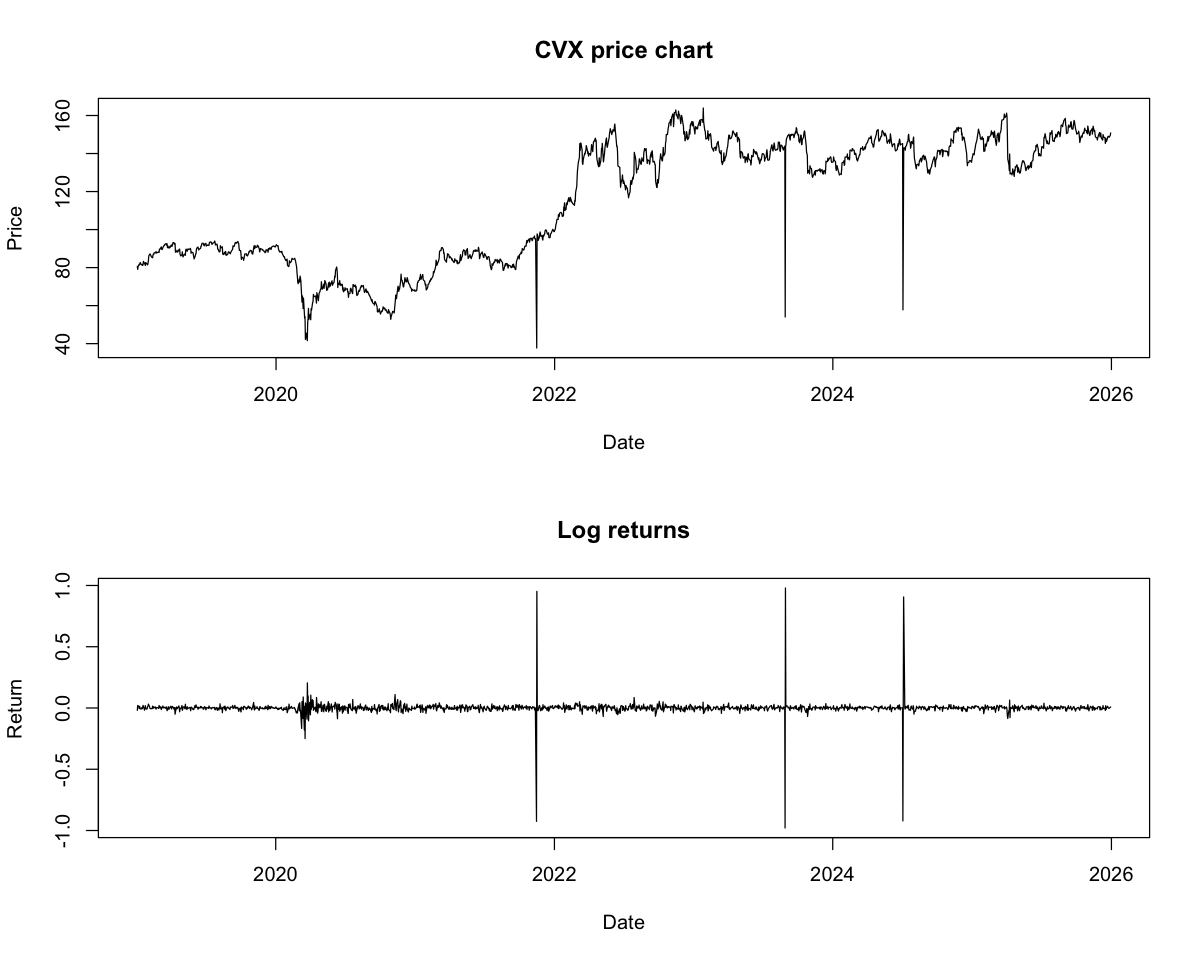

In [10]:
options(repr.plot.width=10, repr.plot.height=8)
par(mfrow=c(2,1))

plot(price_list[["CVX"]]$Date, price_list[["CVX"]]$Close, 
    type='l', main="CVX price chart", xlab="Date", ylab="Price"
)

plot(rets_list[["CVX"]]$Date, rets_list[["CVX"]]$rets, 
    type='l', main="Log returns", xlab="Date", ylab="Return"
)

rets_list[["CVX"]][abs(rets_list[["CVX"]]$rets) > 0.5, ] #to get the exact dates of the outlier dates

Upon further inspection, it can be seen that on 3 occasions, the stock price drops drastically and then recovers the next day. One possibility of such price change would be innapropriate stock split data handling, however `CVX` last stock split was in 2004. As such, it seems that the issue is simply wrong data entry.

To ensure appropriate return modelling and comparison, we trim those observations. Winsorizing would be innapropriate as making an estimate of the returns on those days would affect the return distribution. Given that we have established that those observations are not true outliers, but data handling errors, we find it most appropriate to simply remove them. Trimming at the 50% absolute value of returns is appropriate as no true observations exceed this amount, only the wrong entries.

In [11]:
rets_list[["CVX"]] <- rets_list[["CVX"]][abs(rets_list[["CVX"]]$rets) < 0.5, ] #keep only ret < 50% in magnitude

Mean: 0.0003522917 
SD: 0.02043079 
Min: -0.2500552 
Max: 0.2049111 
Skewness: -1.132913 
Kurtosis: 26.62659

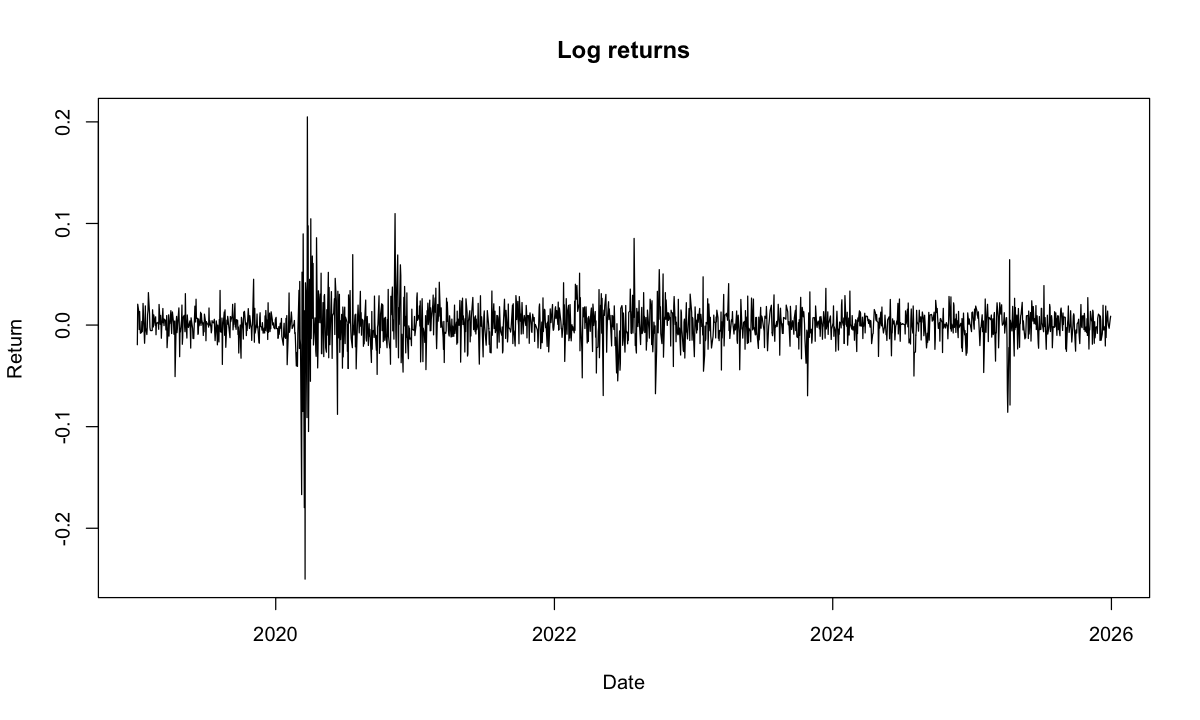

In [12]:
options(repr.plot.width=10, repr.plot.height=6)
plot(rets_list[["CVX"]]$Date, rets_list[["CVX"]]$rets, 
    type='l', main="Log returns", xlab="Date", ylab="Return"
)

CVX <- rets_list[["CVX"]]$rets
cat("Mean:", mean(CVX), 
    "\nSD:", sd(CVX), 
    "\nMin:", min(CVX), 
    "\nMax:", max(CVX), 
    "\nSkewness:", skewness(CVX), 
    "\nKurtosis:", kurtosis(CVX)
)

The issue is fixed.

Still, kurtosis is close to 30 and skewness has a magnitude above 1. 

Nevertheless, we will further investigate the ticker with highest kurtosis out of the sample, as the one to be the furthest away from a normal distribution. This is because kurtosis signals fat tails - extreme events happen more frequently, meanwhile negative skew (what we see in most stocks) simply suggests that most of the density is in a negative area.

### 4. Normality

We identify `FE` to be the ticker with highest lepptokurtic properties (45.2).

agg_record_445146130 
                   2

       alpha         beta        gamma        delta 
 1.559000000 -0.219000000  0.007255068  0.001612289 


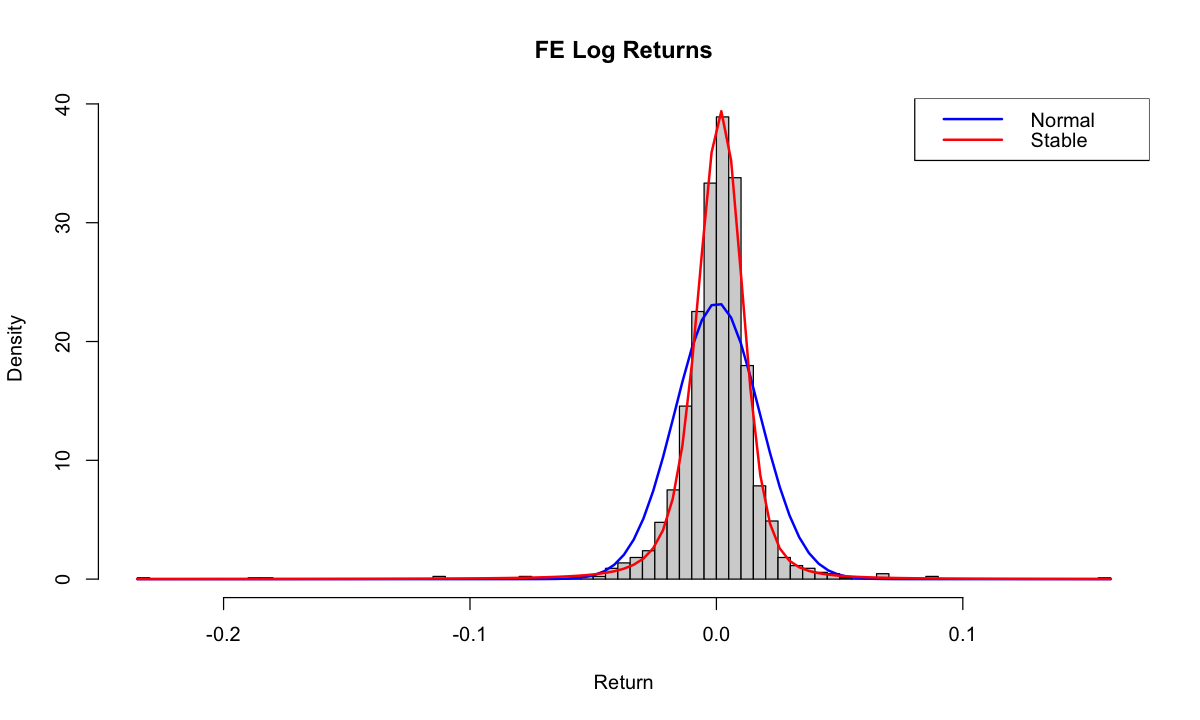

In [13]:
FE <- rets_list[["FE"]]$rets #plotting log returns - more likely to be normal than simple returns

pdf(NULL) #because stableFit produces an unnecessary graph
stable_param <- stableFit(FE, type="q") #fit the stable distrib (get the parameters)
dev.off()

print(stable_param@fit$estimate)
hist(FE, breaks=100, freq=FALSE, main="FE Log Returns", xlab="Return")

curve(dnorm(x, mean=mean(FE), sd=sd(FE)), add=TRUE, col="blue", lwd=2) #normal distrib 

curve(dstable(x,alpha=stable_param@fit$estimate[1], #stable distrib
                beta=stable_param@fit$estimate[2],
                gamma=stable_param@fit$estimate[3],
                delta=stable_param@fit$estimate[4]),
    add=TRUE, col="red", lwd=2
)

legend("topright", legend=c("Normal", "Stable"), col=c("blue", "red"), lwd=2)

- Alpha: tail heaviness 
- Beta: skewness
- Gamma: scale (similar to sd)
- Delta: location (similar to mean)

The stable distribution parameters indicate significant tail risk, slight negative skewness and a location of near zero.

It is evident that using a normal distribution to model `FE`'s stock returns would be greatly inappropriate. The probability of an extreme negative shock to the stock price is much larger than the normal distribution predicts. This can have large implications on portfolio risk management. If the normal distribution is used to model a portfolio return distribution with large kurtosis (and negative skewness), risk measures such as Value at Risk and Expected Shortfall could be largely understated. Failing to appropriately account for tail risk could have devastating consequences. A clearer image of the left tail can be seen below.

The fitted stable distribution has $\alpha$ < 2, which implies a theoretically infinate variance. As such, in practice it comes at a cost. Risk measurement requires some sort of finate second moments.


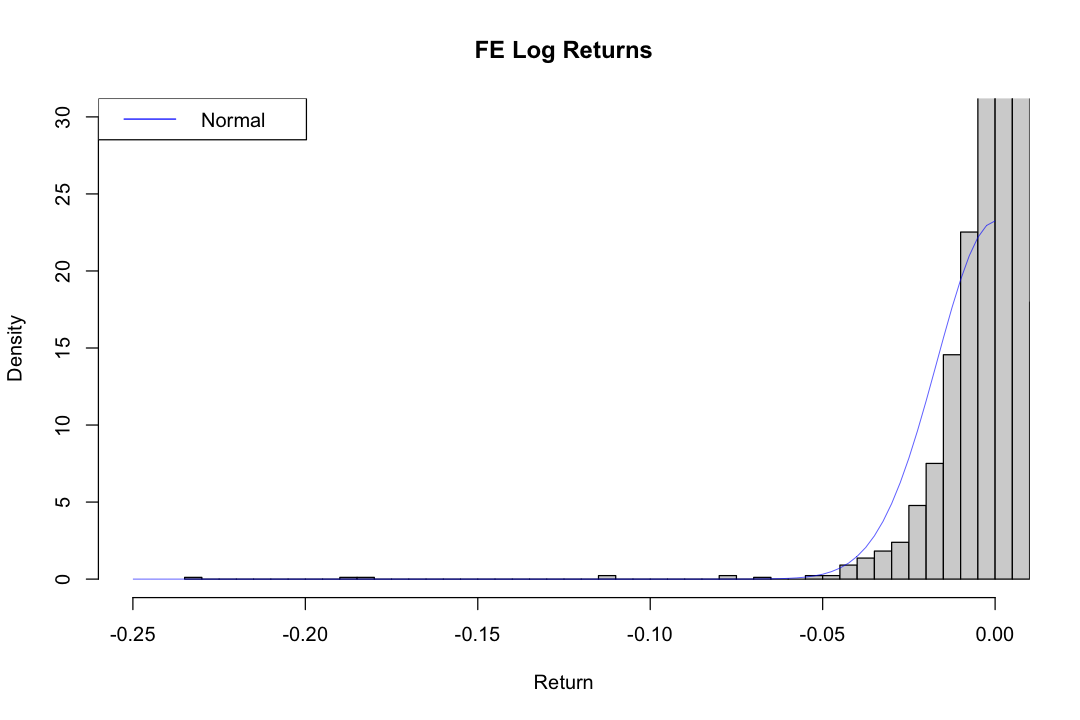

In [27]:
hist(FE, breaks=100, freq=FALSE, main="FE Log Returns", xlab="Return", xlim=c(-0.25, -0), ylim=c(0, 30))
curve(dnorm(x, mean=mean(FE), sd=sd(FE)), add=TRUE, col="blue", lwd=0.5)
legend("topleft", legend="Normal", col="blue", lwd=1)

## Part 2

### 1.

In [44]:
#Checking dates & observations for each stock before combining them 
date_summary <- data.frame( 
    ticker = names(rets_list),
    observations = sapply(rets_list, nrow),
    start_date = as.Date(sapply(rets_list, function(df) min(df$Date))),
    end_date = as.Date(sapply(rets_list, function(df) max(df$Date))) #creating a dataframe with all the stocks 
)
                          
date_summary

,ticker,observations,start_date,end_date
,<chr>,<int>,<date>,<date>
BIO,BIO,1757,2019-01-03,2025-12-30
CPT,CPT,1758,2019-01-03,2025-12-30
ELV,ELV,1757,2019-01-04,2025-12-30
FE,FE,1758,2019-01-03,2025-12-30
HCA,HCA,1758,2019-01-03,2025-12-30
MKTX,MKTX,1758,2019-01-03,2025-12-30
STT,STT,1758,2019-01-03,2025-12-30
XOM,XOM,1756,2019-01-04,2025-12-30
BSX,BSX,1756,2019-01-03,2025-12-30


We can see that all the series cover approximately same time periods (Jan 2019 - Dec 2025) with only 1 day differences in the Start Date. All tickers have around the same number of observations, ranging from 1749 to 1758. Because of the removed bad data points for `CVX` ticker in Part 1, there is a noticeable difference in the number of observations for this stock. However, it is only 9 missing trading days for `CVX` which is not a lot due to the dataset having overall of 1,758 observations and missing days making up only less than 1% of total observations.

In [65]:
#Keeping only time periods with returns that are present for all tickers
stock_list <- lapply(names(rets_list), function(ticker_name) {
  stock_data <- rets_list[[ticker_name]][, c("Date", "rets")]
  colnames(stock_data)[2] <- ticker_name
  stock_data}
)

aligned_rets <- Reduce(function(left, right) merge(left, right, by = "Date"), stock_list)
aligned_rets <- aligned_rets[order(aligned_rets$Date), ]

#Checking the overall state of combined dataset
portfolio_summary <- data.frame(
  trading_days = nrow(aligned_rets),
  number_of_series = ncol(aligned_rets) - 1,
  first_date = as.character(min(aligned_rets$Date)),
  last_date = as.character(max(aligned_rets$Date))
)
                       
portfolio_summary

trading_days,number_of_series,first_date,last_date
<int>,<dbl>,<chr>,<chr>
1733,18,2019-01-04,2025-12-30


After joining all the series, we've obtained 1733 common trading days for all the stocks, ranging from 04.01.2019 to 30.12.2025. The merge uses an inner join, therefore any date where even one ticker is not present gets removed. By doing this, we ensure that the computation of the cross-sectional  is always done for the same list of stocks.

In [66]:
#Seeing the amount rows we lost after aligning dates
obs_lost <- sapply(names(rets_list),function(name) {
    nrow(rets_list[[name]]) - nrow(aligned_rets)}
                  )

sort(obs_lost, decreasing = TRUE)

CPT   FE  HCA MKTX  STT QRVO  BIO  ELV  CAH  ICE MCHP  PHM  XOM  BSX   GM MDLZ 
  25   25   25   25   25   25   24   24   24   24   24   24   23   23   23   23 
 WHR  CVX 
  21   16

We see tiny losses across all the series with the number of rows dropped ranging from 16 to 25. The only stock to pay attention at is `CVX` that has the biggest gap but due to the difference being small, we move forward with all 18 series. 

In [67]:
tickers <- setdiff(colnames(aligned_rets), "Date")

#Computing cross-sectional mean log return
aligned_rets$mean_ret <- rowMeans(aligned_rets[, tickers])

#A summary of mean return series results
mean_stats <- data.frame(
    mean = mean(aligned_rets$mean_ret),
    sd = sd(aligned_rets$mean_ret),
    min = min(aligned_rets$mean_ret),
    q1 = quantile(aligned_rets$mean_ret, 0.25),
    median = median(aligned_rets$mean_ret),
    q3 = quantile(aligned_rets$mean_ret, 0.75),
    max = max(aligned_rets$mean_ret),
    skewness = skewness(aligned_rets$mean_ret),
    kurtosis = kurtosis(aligned_rets$mean_ret)
)

mean_stats

,mean,sd,min,q1,median,q3,max,skewness,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25%,0.0002774959,0.01367917,-0.1633216,-0.005452728,0.0005973788,0.006866844,0.1237977,-1.15847,23.25736


The mean return is roughly zero which is normal as stocks don't fluctuate a lot on a daily basis. The standard deviation (~0.014) is observed to be low than that of the individual stocks due to the averaging all 18 series minimizing the wild fluctuations. There's a slighly negative skewness in the distribution and it's also leptokurtic (kurtosis > 3). This shows that while diversification will reduce tail risk, it will never completely eliminate it. All stocks are affected by a systematic shock in the entire market and these shocks persist in the cross-sectional average.

### 2. 

In [68]:
#Stable distribution fitted to cross-sectional mean returns
mean_rets <- aligned_rets$mean_ret

pdf(NULL)  #suppress the plot stableFit generates
stable_mean <- stableFit(mean_rets, type = "q")
dev.off()

agg_record_1813179418 
                    2

In [69]:
#Comparing with the FE fit from Part 1
comparison <- data.frame(
    parameter = c("alpha", 
                  "beta", 
                  "gamma", 
                  "delta"),
    FE = stable_param@fit$estimate,
    mean_returns = stable_mean@fit$estimate
)

comparison

,parameter,FE,mean_returns
,<chr>,<dbl>,<dbl>
alpha,alpha,1.559000000,1.5730000000
beta,beta,-0.219000000,-0.1410000000
gamma,gamma,0.007255068,0.0063665530
delta,delta,0.001612289,0.0007818058


Comparison parameters:

- Alpha: There is a slightly greater alpha (1.573) in the mean returns than in FE (1.559) which means slightly "lighter" tails. Although this difference is small, it indicates that although an average over 18 stocks will reduce idiosyncratic tail risks, it will have only a minor impact on alpha, and both are still much lower than 2, indicating heavy tailed characteristics exist in the cross sectional mean.
- Beta: The skewness parameter has decreased from -0.219 (FE) to -0.141 (mean returns) which means less negative skewness exists in the data. It would be logical to expect that the negative skewness that existed in each of the 18 individual stocks, would cancel out when they were averaged. However, there is a residual negative skewness remaining due to market wide declines that affect all of the stocks at the same time.
- Gamma: Has decreased from 0.00726 (FE) to 0.00637 (mean returns). A gamma value acts as a scale factor, so the reduction in gamma is reflective of the decline in dispersion from averaging.
- Delta: Delta values are similar for both FE (0.00161) and mean returns (0.00078) and should be near zero since daily returns, and are centered about zero regardless if looking at one stock or the portfolio averages.

In total, the cross-sectional mean appears to be slightly more normally distributed (greater alpha, less skewness, smaller scale) but the changes are minimal. Both distributions are clearly non-gaussian and exhibit heavy-tailed characteristics ($\alpha$ < 2), and therefore confirm that diversification can reduce, but will not completely remove heavy-tail characteristics.

### 3.

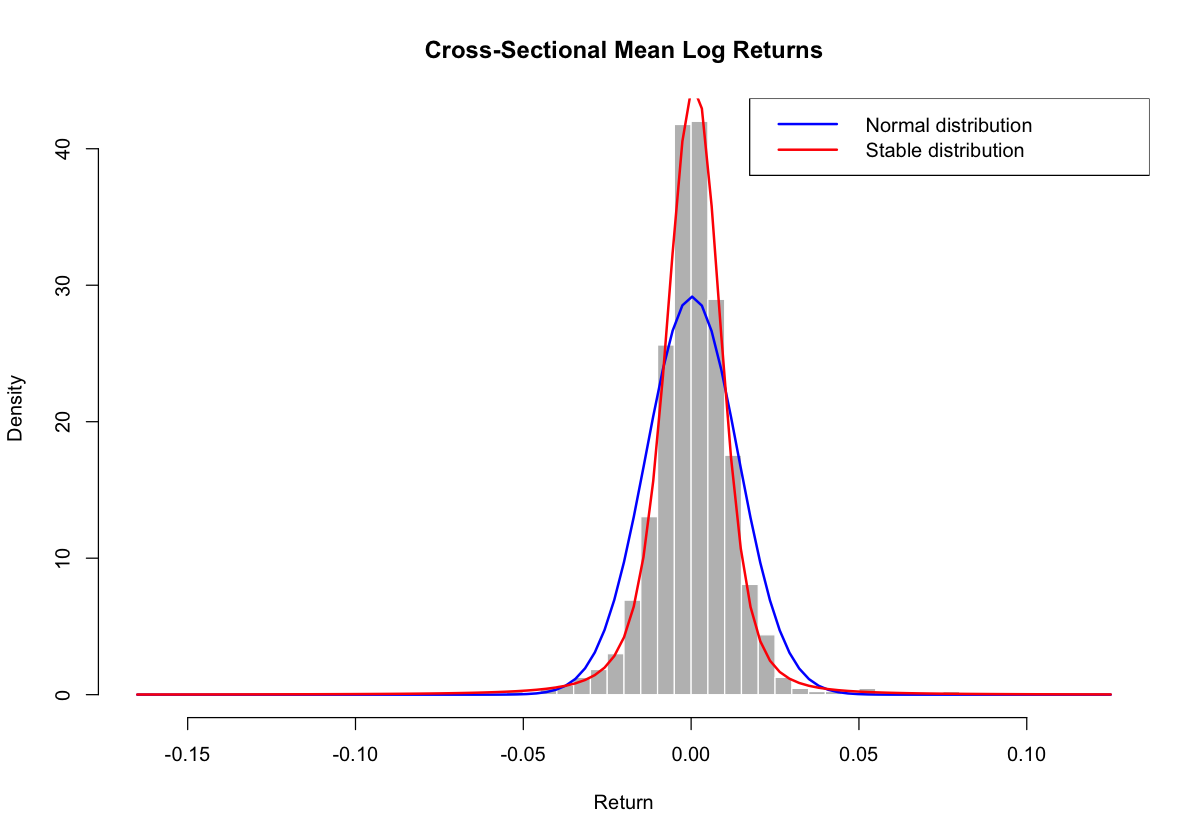

In [70]:
#Plotting histogram of the mean returns
options(repr.plot.width = 10, repr.plot.height = 7)

stable_parameters <- stable_mean@fit$estimate
alpha_value <- stable_parameters[1]
beta_value  <- stable_parameters[2]
gamma_value <- stable_parameters[3]
delta_value <- stable_parameters[4]

hist(mean_rets,
     breaks = 80,
     freq = FALSE,
     main = "Cross-Sectional Mean Log Returns",
     xlab = "Return",
     col = "grey",
     border = "white")

#Comparing normal vs stable fit
curve(dnorm(x, mean = mean(mean_rets), sd = sd(mean_rets)),
      add = TRUE, col = "blue", lwd = 2)

curve(dstable(x,
              alpha = alpha_value,
              beta = beta_value,
              gamma = gamma_value,
              delta = delta_value),
      add = TRUE, col = "red", lwd = 2)

legend("topright",
       legend = c("Normal distribution", "Stable distribution"),
       col = c("blue", "red"),
       lwd = 2)

This is consistent with the parameter estimates and the histogram shown above; the red line representing the stable distribution matches the blue line representing the normal distribution, yet the stable distribution fits the data much better. And it explains why we see a high peak near zero and why we observe heaver tails on both sides, whereas the normal distribution is too flat around the middle, and overestimates density around 0.02. Also, it underestimates the probability of both large and small returns. 

A slight asymmetry towards the left tail is observable, and is consistent with the negative beta (-0.141) estimated by the stable fit. As compared to the FE histogram from Part 1, this shape is generally more narrow, and has a higher concentration of observations around zero due to the lower volatility observed when averaging the 18 stocks included in the sample. Nonetheless, the gap between the normal and stable fit clearly demonstrates that even after diversification, a Gaussian model would not be capable of accurately modeling the true return distribution.

### 4.

In [71]:
#Descriptive stats for the cross-sectional mean returns
mean_desc <- data.frame(
    mean = mean(mean_rets),
    sd = sd(mean_rets),
    min = min(mean_rets),
    max = max(mean_rets),
    skewness = skewness(mean_rets),
    kurtosis = kurtosis(mean_rets)
)

mean_desc

mean,sd,min,max,skewness,kurtosis
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.0002774959,0.01367917,-0.1633216,0.1237977,-1.15847,23.25736


The cross-sectional mean had a daily mean return with an average of approximately zero (~0.00028), a standard deviation of 0.0137 and ranged from -0.163 to 0.124. Compared to individual stocks (where SDs range from 0.013 to 0.032), the mean return series was significantly less volatile. However, a skewness of -1.16 and kurtosis of 23.3, showed that the distribution remained very far from being normal.

In [72]:
#Recalculate descriptive statistics for each stock
stock_stats <- do.call(rbind, lapply(names(rets_list), function(ticker_name) {
  returns <- rets_list[[ticker_name]]$rets

  data.frame(
    ticker = ticker_name,
    mean = mean(returns),
    sd = sd(returns),
    min = min(returns),
    max = max(returns),
    skew = skewness(returns),
    kurt = kurtosis(returns))}
))


mean_stats <- data.frame(
  ticker = "CS_MEAN",
  mean = mean(mean_rets),
  sd = sd(mean_rets),
  min = min(mean_rets),
  max = max(mean_rets),
  skew = skewness(mean_rets),
  kurt = kurtosis(mean_rets)
)

comparison <- rbind(stock_stats, mean_stats)
format(comparison, digits = 4)

,ticker,mean,sd,min,max,skew,kurt
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
1,BIO,1.645e-04,0.02273,-0.1830,0.16235,-0.02129,6.936
2,CPT,2.887e-04,0.01687,-0.1971,0.10530,-0.91603,16.263
3,ELV,-1.211e-03,0.02700,-0.2571,0.13551,-3.71133,30.976
4,FE,2.780e-04,0.01716,-0.2345,0.15647,-2.66956,42.103
5,HCA,8.070e-04,0.02235,-0.2462,0.20343,-0.83526,20.541
6,MKTX,-3.970e-05,0.02238,-0.2079,0.14965,-0.82904,9.888
7,STT,5.292e-04,0.02257,-0.2098,0.20147,-0.38249,11.392
8,XOM,-9.024e-04,0.02604,-0.2687,0.11283,-4.04841,36.392
9,BSX,5.835e-04,0.01704,-0.1600,0.08849,-0.89783,8.273


Comparative analysis of `CS_MEAN` vs. Individual Stocks:

SD - `CS_MEAN` (0.0137) is lower than all individual stocks. `MDLZ` is the least volatile stock at 0.0134; however, most stocks have SDs of 0.017-0.032. Thus, averaging across 18 assets reduces volatility, because the idiosyncratic movements in individual stocks will partially offset one another.

Extreme values - The cross-sectional mean's min/max values of -0.163, 0.124 were relatively moderate when compared to the individual stock's worst cases:`QRVO` Min = -0.319, `WHR` Max = 0.259. Stock-specific shocks are diluted when averaged.

Skewness - `CS_MEAN` had a skewness of -1.16, which is even more negative than for the majority of individual stocks. This implies that on days where the market drops, the majority of stocks drop together and the common crash effect is magnified in the average. The positive skewness of individual stocks are also eliminated.

Kurtosis - `CS_MEAN` (23.3) was greater than many individual stocks (`GM = 6.6`), but lower than the most extreme (`XOM = 36.4`). The high kurtosis in the average is due to market-wide extreme days that impact all stocks at the same time.

In summary, diversification successfully reduced volatility and reduced individual extremes, however it also amplified the relative impact of market wide shocks.

## Problem 2.

We create 500 simulations of random walks without drift, each with 1000 steps, defined by

$$
X_t = X_{t-1} + \varepsilon_t,
$$

where

$$
\varepsilon_t \sim N(0, \sigma^2), \qquad X_0 = 0.
$$

In addition, we repeat the simulation for two different levels of volatility: a low-variance case with

$$
\sigma = 0.5
$$

and a high-variance case with

$$
\sigma = 2.0.
$$

This allows us to compare how the variance of the random walk increases over time under different disturbance variances.

In [62]:
#Setting values for simulation 

set.seed(123)

simulations <- 500
series_l <- 1000

low_sigma <- 0.5
high_sigma <- 2.0

#Simulating random walks without drift
low_noise <- matrix(rnorm(series_l * simulations, sd = low_sigma), nrow = series_l)
high_noise <- matrix(rnorm(series_l * simulations, sd = high_sigma), nrow = series_l)

rw_low <- apply(low_noise, 2, cumsum)
rw_high <- apply(high_noise, 2, cumsum)

In [74]:
plot_random_walks <- function(random_walks, sigma_value, line_color) {

  time_index <- 1:nrow(random_walks)

  q_25 <- apply(random_walks, 1, quantile, probs = 0.25)
  q_50 <- apply(random_walks, 1, median)
  q_75 <- apply(random_walks, 1, quantile, probs = 0.75)

  upper_bound <- 2 * sigma_value * sqrt(time_index)
  lower_bound <- -2 * sigma_value * sqrt(time_index)

  plot(NULL,
       xlim = c(1, length(time_index)),
       ylim = range(random_walks),
       xlab = "Time",
       ylab = expression(X[t]),
       main = paste("Random Walk without Drift, sigma =", sigma_value))

  chosen_paths <- sample(1:ncol(random_walks), 30)
  for (j in chosen_paths) {
    lines(time_index, random_walks[, j],
          col = adjustcolor(line_color, alpha.f = 0.15), lwd = 0.5)}

  polygon(c(time_index, rev(time_index)),
          c(q_25, rev(q_75)),
          col = adjustcolor(line_color, alpha.f = 0.3),
          border = NA)

  lines(time_index, q_50, col = line_color, lwd = 2)
  lines(time_index, upper_bound, col = "black", lty = 2)
  lines(time_index, lower_bound, col = "black", lty = 2)

  legend("topleft",
         legend = c("Sample paths", "Middle 50%", "Median", "Theoretical bounds"),
         col = c(adjustcolor(line_color, alpha.f = 0.3),
                 adjustcolor(line_color, alpha.f = 0.3),
                 line_color,
                 "black"),
         lwd = c(1, 8, 2, 1),
         lty = c(1, 1, 1, 2),
         bty = "n")}

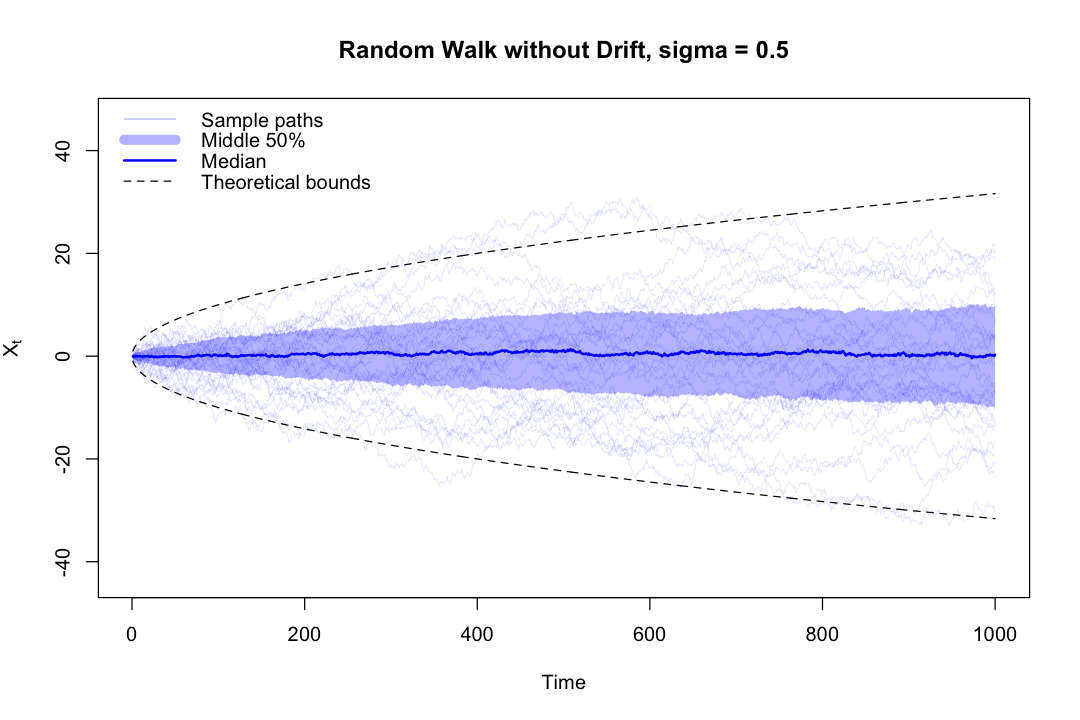

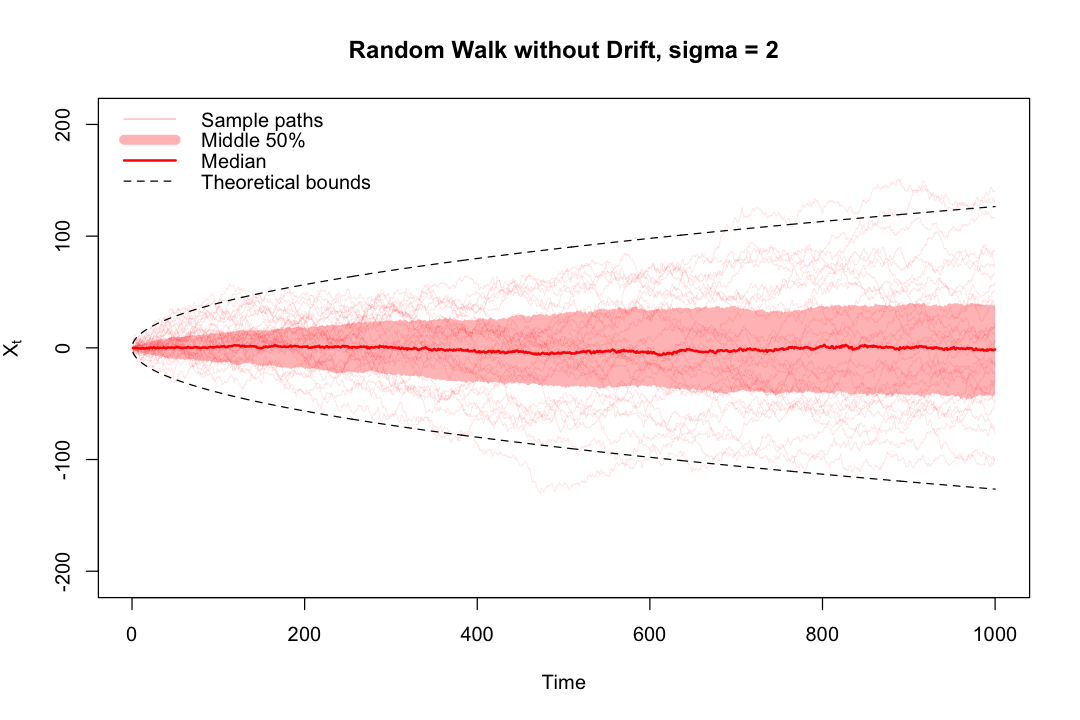

In [76]:
#Low-volatility case
options(repr.plot.width = 9, repr.plot.height = 6)
plot_random_walks(rw_low, 0.5, "blue")

#High-volatility case
plot_random_walks(rw_high, 2, "red")

The plots show that the paths of a random walk fan out over time. As time progresses, the distance between the paths becomes larger, which reflects the increasing uncertainty of the process. Since there is no force pulling the process back toward zero, the paths can continue to drift farther away from the starting point.

In addition, the shaded interquartile range (IQR) band starts narrow and gradually widens, which is consistent with the fact that

$$
\operatorname{Var}(X_t) = \sigma^2 t.
$$

The dashed theoretical bounds,

$$
\pm 2\sigma\sqrt{t},
$$

provide a good approximation of the dispersion in the simulated data, since most of the simulated paths remain within these limits.

Comparing the two plots, the case with

$$
\sigma = 2.0
$$

shows substantially wider dispersion than the case with

$$
\sigma = 0.5.
$$

This is expected, because the variability of the random walk increases with $\sigma$. Since there is no drift term, the median path in both cases remains close to zero over time.

The main conclusion is that the uncertainty of a random walk grows without bound as the forecast horizon increases. The further into the future we try to predict, the wider the confidence interval becomes.